[![session-10](Sesion10_banner.png)](https://github.com/semilleroCV/Hands-on-Computer-Vision/tree/main/sesiones/sesion10)

# <font color="EB9A54"><center> **Hands-on Sesión 10: De imágenes térmicas a estimación de profundidad 📚🌡️** </center></font>

En este notebook veremos que una imagen térmica es una modalidad más de visión por computadora. Al igual que una imagen espectral, cada píxel contiene una firma a varias longitudes de onda; y, al igual que en estimación de profundidad, utilizaremos esas mediciones para inferir propiedades de la escena.

Partiremos de la medición producida por el modelo directo del notebook anterior y recorreremos el camino inverso: ajustaremos los parámetros de la escena mediante descenso por gradiente.

## <font color='#4C5FDA'> **Contenido**</font>

[**1. Cargar y representar la escena térmica espectral**](#tema1)

[**2. Recuperar la medición del modelo directo**](#tema2)

[**3. Formular el problema inverso**](#tema3)

[**4. Optimizar los parámetros de la escena**](#tema4)

[**5. Evaluar la profundidad estimada**](#tema5)

[**6. Analizar la temperatura y la emisividad espectral**](#tema6)

# <font color="4C5FDA"> **1. Cargar y representar la escena térmica espectral** </font><a id="tema1"></a>

Usaremos los mismos datos del notebook anterior. Para que la optimización sea rápida, tomaremos una muestra espacial regular de la escena, pero conservaremos sus 49 bandas espectrales.

In [1]:
#@title **Cargar librerías y descargar los datos**
%matplotlib inline

from pathlib import Path

import gdown
import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import c, h, k

folder_id = "1d150jOzFGBY0eea_Ak1kgLSU70OnwaC7"
data_dir = Path("data")
required_files = [
    "depth.npy",
    "emap.npy",
    "emissivity.npy",
    "matName_FullDatabase.npy",
    "scene.png",
    "tmap.npy",
    "wavelengths.npy",
    "atmospheres/enclosure.txt",
]

if not all((data_dir / filename).exists() for filename in required_files):
    gdown.download_folder(id=folder_id, output="./", quiet=False)

missing_files = [filename for filename in required_files if not (data_dir / filename).exists()]
if missing_files:
    raise FileNotFoundError(f"La descarga está incompleta. Faltan: {missing_files}")

print(f"Datos disponibles en: {data_dir}")

Datos disponibles en: data


In [2]:
#@title **Cargar una muestra espacial de la escena**
spatial_stride = 20

wavelengths = np.load(data_dir / "wavelengths.npy").astype(np.float32)
depth_truth = np.load(data_dir / "depth.npy", mmap_mode="r")[
    ::spatial_stride, ::spatial_stride
].astype(np.float32)
temperature_truth_c = np.load(data_dir / "tmap.npy", mmap_mode="r")[
    ::spatial_stride, ::spatial_stride
].astype(np.float32)
material_map = np.load(data_dir / "emap.npy", mmap_mode="r")[
    ::spatial_stride, ::spatial_stride
].astype(np.int32)
emissivity_truth = np.load(data_dir / "emissivity.npy", mmap_mode="r")[
    ::spatial_stride, ::spatial_stride, :
].astype(np.float32)

raw_names = np.load(
    data_dir / "matName_FullDatabase.npy", allow_pickle=True
).item()["matName"]
material_names = np.hstack(raw_names.squeeze())

assert emissivity_truth.shape == (*depth_truth.shape, len(wavelengths))
assert depth_truth.shape == temperature_truth_c.shape == material_map.shape

# El identificador 0 corresponde al cielo. Lo excluiremos del problema inverso:
# su profundidad está saturada en 100 m y no representa un objeto finito.
object_mask = material_map != 0

print(f"Muestra espacial: {depth_truth.shape[1]} × {depth_truth.shape[0]} píxeles")
print(f"Bandas espectrales: {len(wavelengths)}")
print(f"Píxeles de objetos usados: {object_mask.sum()}")

Muestra espacial: 96 × 54 píxeles
Bandas espectrales: 49
Píxeles de objetos usados: 4953


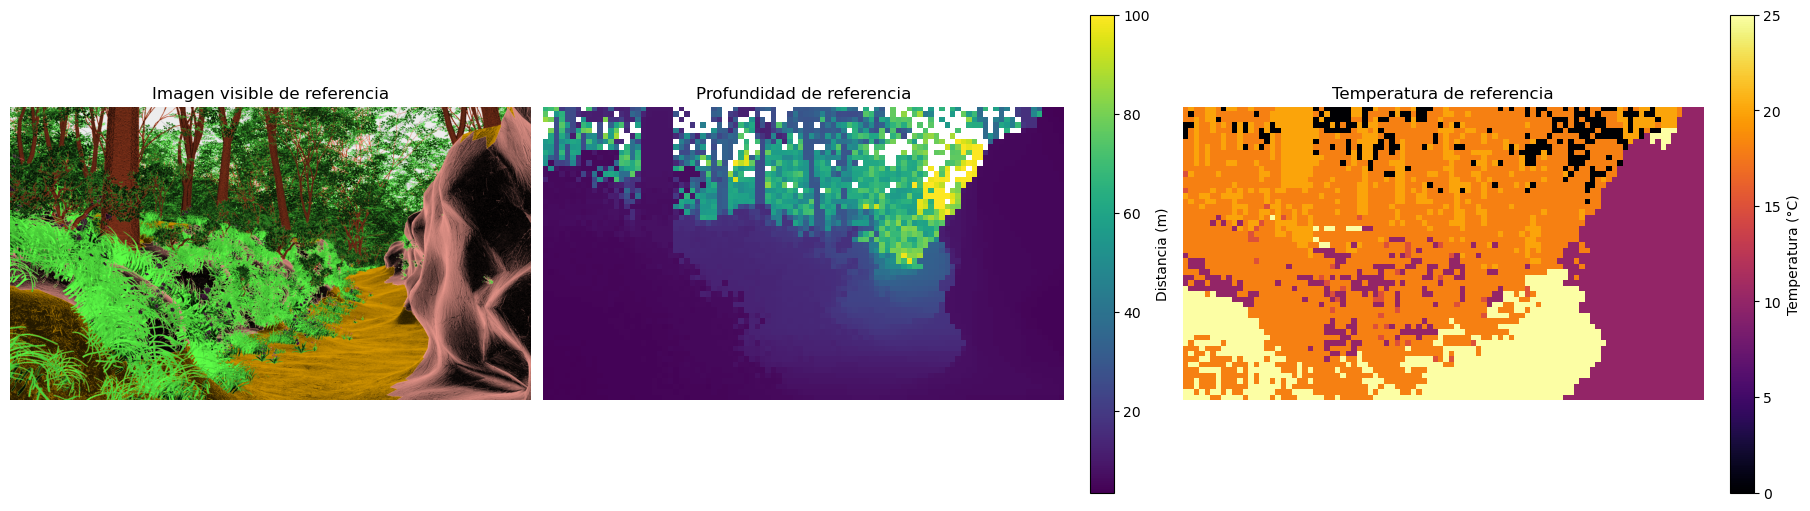

In [3]:
#@title **Visualizar la escena de referencia**
scene_reference = plt.imread(data_dir / "scene.png")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
axes[0].imshow(scene_reference)
axes[0].set_title("Imagen visible de referencia")
axes[0].axis("off")

depth_image = axes[1].imshow(np.where(object_mask, depth_truth, np.nan), cmap="viridis")
axes[1].set_title("Profundidad de referencia")
axes[1].axis("off")
fig.colorbar(depth_image, ax=axes[1], label="Distancia (m)")

temperature_image = axes[2].imshow(temperature_truth_c, cmap="inferno")
axes[2].set_title("Temperatura de referencia")
axes[2].axis("off")
fig.colorbar(temperature_image, ax=axes[2], label="Temperatura (°C)")
plt.show()

# <font color="4C5FDA"> **2. Recuperar la medición del modelo directo** </font><a id="tema2"></a>

El resultado final del notebook anterior puede escribirse, para cada píxel, como

Como los notebooks no comparten automáticamente sus variables, reconstruiremos aquí una muestra pequeña de esa misma medición antes de ejecutar únicamente el backward.

$$
L_{\mathrm{sensor}}(\lambda)
=\tau(\lambda,d)\,\varepsilon(\lambda)B(\lambda;T_{\mathrm{object}})
+[1-\tau(\lambda,d)]B(\lambda;T_{\mathrm{air}})+n(\lambda).
$$

La atmósfera y su temperatura se consideran conocidas. La distancia $d$, la temperatura del objeto y su emisividad espectral serán las incógnitas del problema inverso.

In [4]:
def blackbody(temperature_k):
    # Radiancia de cuerpo negro para todos los píxeles y bandas.
    wavelength_m = wavelengths[None, :] * 1e-6
    temperature_k = np.asarray(temperature_k, dtype=np.float32).reshape(-1, 1)
    exponent = h * c / (wavelength_m * k * temperature_k)
    radiance = (2 * h * c**2) / (wavelength_m**5 * np.expm1(exponent))
    return (radiance * 1e-4).astype(np.float32)


def d_blackbody_d_temperature(temperature_k):
    # Derivada analítica de B(lambda; T) respecto a T.
    wavelength_m = wavelengths[None, :] * 1e-6
    temperature_k = np.asarray(temperature_k, dtype=np.float32).reshape(-1, 1)
    exponent = h * c / (wavelength_m * k * temperature_k)
    exp_exponent = np.exp(exponent)
    scale = (2 * h * c**2) / wavelength_m**5 * 1e-4
    derivative = (
        scale
        * exp_exponent
        * exponent
        / (temperature_k * (exp_exponent - 1) ** 2)
    )
    return derivative.astype(np.float32)


atmosphere_table = np.loadtxt(data_dir / "atmospheres" / "enclosure.txt")
attenuation_db = np.interp(
    wavelengths, atmosphere_table[:, 0], atmosphere_table[:, 2]
).astype(np.float32)


def transmittance(depth_m):
    # Transmitancia de la envolvente para cada distancia y banda.
    depth_m = np.asarray(depth_m, dtype=np.float32).reshape(-1, 1)
    return (10 ** (-depth_m * attenuation_db[None, :] / 10)).astype(np.float32)

In [5]:
#@title **Reproducir la medición ruidosa del sensor**
height, width = depth_truth.shape
depth_vector = depth_truth.reshape(-1)
temperature_vector_k = temperature_truth_c.reshape(-1) + 273.15
emissivity_matrix = emissivity_truth.reshape(-1, len(wavelengths))

air_temperature_k = 288.0
air_blackbody = blackbody([air_temperature_k])[0]
object_blackbody = blackbody(temperature_vector_k)
transmittance_matrix = transmittance(depth_vector)

clean_radiance = (
    transmittance_matrix * emissivity_matrix * object_blackbody
    + (1 - transmittance_matrix) * air_blackbody
)

noise_fraction = 0.01
noise_std = noise_fraction * np.percentile(clean_radiance, 99)
rng = np.random.default_rng(314)
sensor_radiance = clean_radiance + rng.normal(
    0, noise_std, size=clean_radiance.shape
).astype(np.float32)
sensor_cube = sensor_radiance.reshape(height, width, -1)

print(f"Cubo térmico espectral medido: {sensor_cube.shape}")
print(f"Desviación estándar del ruido: {noise_std:.4f} µW/(cm²·sr·µm)")

Cubo térmico espectral medido: (54, 96, 49)
Desviación estándar del ruido: 8.2727 µW/(cm²·sr·µm)


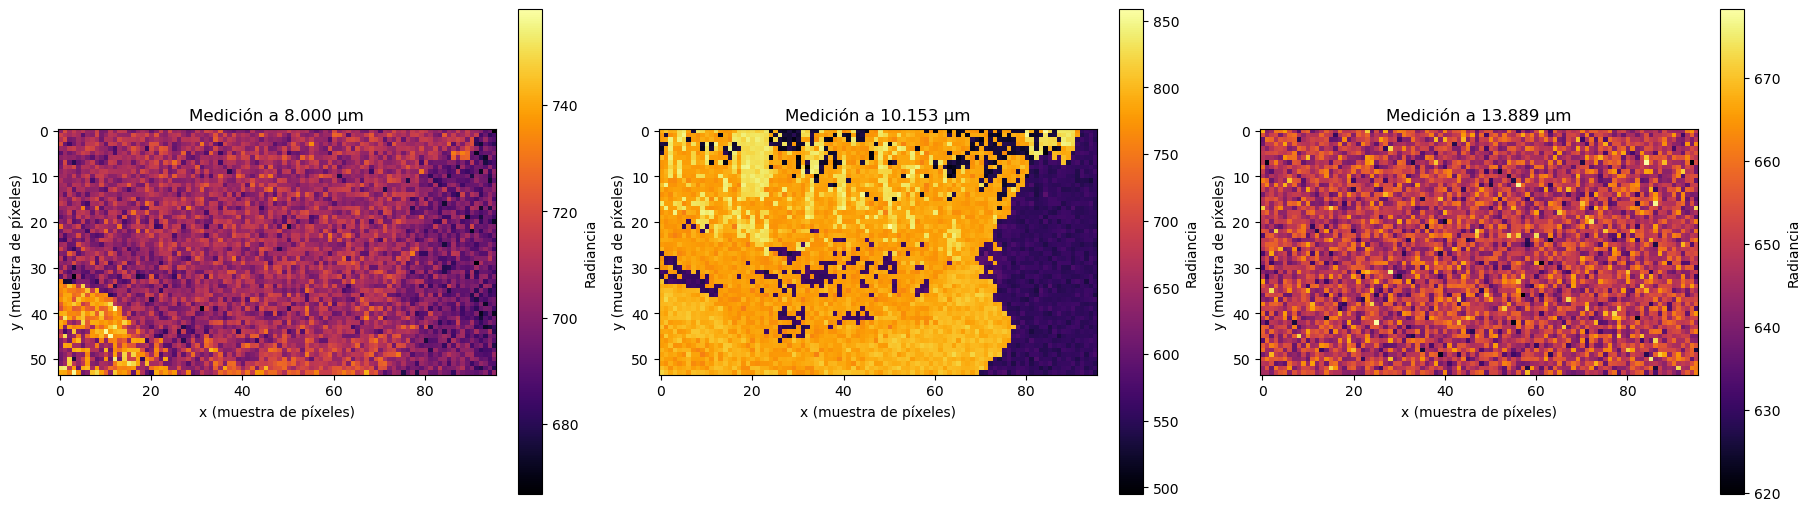

In [6]:
#@title **Visualizar bandas de la imagen térmica espectral**
band_indices = [0, len(wavelengths) // 2, len(wavelengths) - 1]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for axis, band in zip(axes, band_indices):
    image = axis.imshow(sensor_cube[:, :, band], cmap="inferno")
    axis.set_title(f"Medición a {wavelengths[band]:.3f} µm")
    axis.set_xlabel("x (muestra de píxeles)")
    axis.set_ylabel("y (muestra de píxeles)")
    fig.colorbar(image, ax=axis, label="Radiancia")

plt.show()

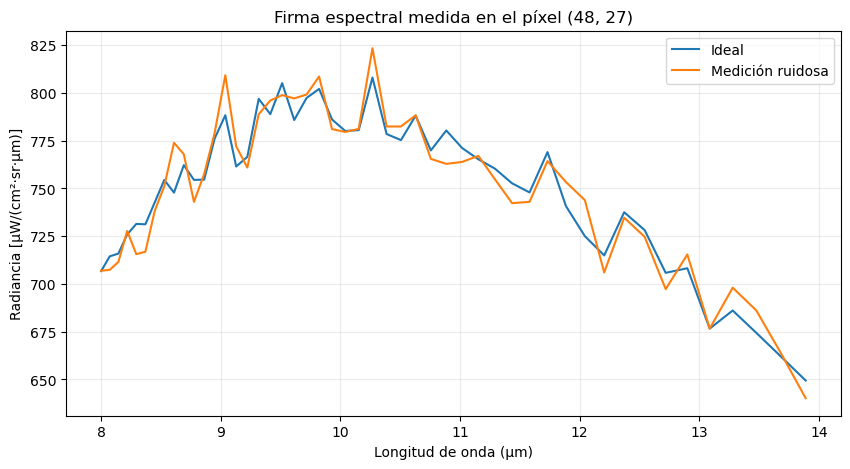

In [7]:
#@title **Examinar la medición espectral de un píxel**
pixel_y, pixel_x = 27, 48

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, clean_radiance.reshape(height, width, -1)[pixel_y, pixel_x], label="Ideal")
plt.plot(wavelengths, sensor_cube[pixel_y, pixel_x], label="Medición ruidosa", linewidth=1.5)
plt.xlabel("Longitud de onda (µm)")
plt.ylabel("Radiancia [µW/(cm²·sr·µm)]")
plt.title(f"Firma espectral medida en el píxel ({pixel_x}, {pixel_y})")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

# <font color="4C5FDA"> **3. Formular el problema inverso** </font><a id="tema3"></a>

Buscaremos parámetros que minimicen el error entre la medición y la predicción del modelo:

$$
\mathcal{L}=\frac{1}{N_{\lambda}}\sum_{\lambda}
\left(\frac{\widehat L_{\mathrm{sensor}}(\lambda)-L_{\mathrm{sensor}}(\lambda)}{s}\right)^2.
$$

Sin restricciones, cada píxel tendría 51 incógnitas —distancia, temperatura y 49 emisividades— pero solo 49 mediciones. Para obtener una primera solución identificable, representaremos la emisividad mediante siete puntos de control e interpolaremos una curva suave de 49 bandas. Así, cada píxel tendrá nueve incógnitas y 49 observaciones.

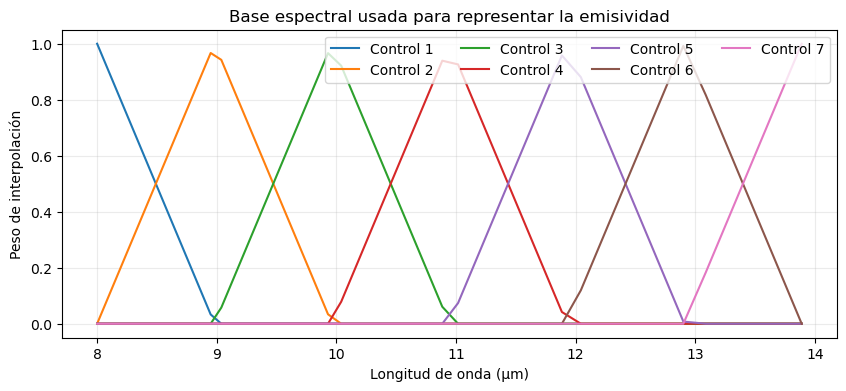

In [8]:
#@title **Construir una representación compacta de la emisividad**
n_emissivity_controls = 7
control_wavelengths = np.linspace(wavelengths[0], wavelengths[-1], n_emissivity_controls)
emissivity_basis = np.stack(
    [
        np.interp(
            wavelengths,
            control_wavelengths,
            np.eye(n_emissivity_controls)[control],
        )
        for control in range(n_emissivity_controls)
    ],
    axis=1,
).astype(np.float32)

plt.figure(figsize=(10, 4))
for control in range(n_emissivity_controls):
    plt.plot(wavelengths, emissivity_basis[:, control], label=f"Control {control + 1}")
plt.xlabel("Longitud de onda (µm)")
plt.ylabel("Peso de interpolación")
plt.title("Base espectral usada para representar la emisividad")
plt.grid(alpha=0.25)
plt.legend(ncol=4)
plt.show()

Las derivadas del modelo directo son

$$
\frac{\partial \widehat L}{\partial \varepsilon}
=\tau B(\lambda;T_{\mathrm{object}}),
$$

$$
\frac{\partial \widehat L}{\partial d}
=\frac{\partial\tau}{\partial d}
\left[\varepsilon B(\lambda;T_{\mathrm{object}})-B(\lambda;T_{\mathrm{air}})\right],
\qquad
\frac{\partial\tau}{\partial d}
=-\frac{\ln(10)}{10}\alpha(\lambda)\tau,
$$

$$
\frac{\partial \widehat L}{\partial T_{\mathrm{object}}}
=\tau\varepsilon\frac{\partial B(\lambda;T_{\mathrm{object}})}{\partial T_{\mathrm{object}}}.
$$

Calcularemos estas derivadas explícitamente. Usaremos Adam como una variante adaptativa del descenso por gradiente y proyectaremos cada actualización a un intervalo físico.

# <font color="4C5FDA"> **4. Optimizar los parámetros de la escena** </font><a id="tema4"></a>

La verdad de referencia se entrega a la función únicamente para calcular métricas durante esta demostración; no participa en los gradientes ni en las actualizaciones.

In [9]:
def adam_update(parameter, gradient, state, learning_rate, iteration):
    # Una actualización de descenso por gradiente adaptativo.
    beta_1, beta_2 = 0.9, 0.999
    state[0] = beta_1 * state[0] + (1 - beta_1) * gradient
    state[1] = beta_2 * state[1] + (1 - beta_2) * gradient**2
    first_moment = state[0] / (1 - beta_1**iteration)
    second_moment = state[1] / (1 - beta_2**iteration)
    parameter -= learning_rate * first_moment / (np.sqrt(second_moment) + 1e-8)


def inverse_gradient_descent(
    observed_radiance,
    iterations=800,
    record_every=40,
    depth_truth=None,
    temperature_truth_c=None,
    emissivity_truth=None,
):
    # Estimar distancia, temperatura y emisividad espectral por píxel.
    n_pixels, n_bands = observed_radiance.shape
    radiance_scale = np.maximum(observed_radiance.mean(axis=1, keepdims=True), 1.0)

    predicted_depth = np.full(n_pixels, 20.0, dtype=np.float32)
    predicted_temperature_k = np.full(n_pixels, 18.0 + 273.15, dtype=np.float32)
    emissivity_controls = np.full(
        (n_pixels, n_emissivity_controls), 0.9, dtype=np.float32
    )

    states = {
        "depth": [np.zeros_like(predicted_depth), np.zeros_like(predicted_depth)],
        "temperature": [
            np.zeros_like(predicted_temperature_k),
            np.zeros_like(predicted_temperature_k),
        ],
        "emissivity": [
            np.zeros_like(emissivity_controls),
            np.zeros_like(emissivity_controls),
        ],
    }
    attenuation_factor = -(np.log(10.0) / 10.0) * attenuation_db[None, :]
    history = []

    for iteration in range(iterations + 1):
        predicted_emissivity = emissivity_controls @ emissivity_basis.T
        object_term = blackbody(predicted_temperature_k)
        transmission = transmittance(predicted_depth)
        prediction = air_blackbody + transmission * (
            predicted_emissivity * object_term - air_blackbody
        )

        normalized_residual = (prediction - observed_radiance) / radiance_scale

        if iteration % record_every == 0 or iteration == iterations:
            row = {
                "iteration": iteration,
                "radiance_rmse": float(np.sqrt(np.mean(normalized_residual**2))),
            }
            if depth_truth is not None:
                row["depth_rmse"] = float(
                    np.sqrt(np.mean((predicted_depth - depth_truth) ** 2))
                )
            if temperature_truth_c is not None:
                row["temperature_rmse"] = float(
                    np.sqrt(
                        np.mean(
                            (predicted_temperature_k - 273.15 - temperature_truth_c) ** 2
                        )
                    )
                )
            if emissivity_truth is not None:
                row["emissivity_rmse"] = float(
                    np.sqrt(np.mean((predicted_emissivity - emissivity_truth) ** 2))
                )
            history.append(row)

        if iteration == iterations:
            break

        residual_factor = (
            (2.0 / n_bands)
            * (prediction - observed_radiance)
            / radiance_scale**2
        )
        gradient_depth = np.sum(
            residual_factor
            * transmission
            * attenuation_factor
            * (predicted_emissivity * object_term - air_blackbody),
            axis=1,
        )
        gradient_temperature = np.sum(
            residual_factor
            * transmission
            * predicted_emissivity
            * d_blackbody_d_temperature(predicted_temperature_k),
            axis=1,
        )
        gradient_emissivity = (
            residual_factor * transmission * object_term
        ) @ emissivity_basis

        adam_update(
            predicted_depth, gradient_depth, states["depth"], 0.30, iteration + 1
        )
        adam_update(
            predicted_temperature_k,
            gradient_temperature,
            states["temperature"],
            0.07,
            iteration + 1,
        )
        adam_update(
            emissivity_controls,
            gradient_emissivity,
            states["emissivity"],
            0.002,
            iteration + 1,
        )

        np.clip(predicted_depth, 0.0, 120.0, out=predicted_depth)
        np.clip(predicted_temperature_k, 273.15, 313.15, out=predicted_temperature_k)
        np.clip(emissivity_controls, 0.6, 1.0, out=emissivity_controls)

    return {
        "depth": predicted_depth,
        "temperature_c": predicted_temperature_k - 273.15,
        "emissivity": emissivity_controls @ emissivity_basis.T,
        "radiance": prediction,
        "history": history,
    }

In [10]:
#@title **Ejecutar el descenso por gradiente**
observed_objects = sensor_cube[object_mask]
depth_objects = depth_truth[object_mask]
temperature_objects_c = temperature_truth_c[object_mask]
emissivity_objects = emissivity_truth[object_mask]

inverse_result = inverse_gradient_descent(
    observed_objects,
    iterations=800,
    record_every=40,
    depth_truth=depth_objects,
    temperature_truth_c=temperature_objects_c,
    emissivity_truth=emissivity_objects,
)

initial_metrics = inverse_result["history"][0]
final_metrics = inverse_result["history"][-1]
print("Métricas iniciales:", initial_metrics)
print("Métricas finales:", final_metrics)

Métricas iniciales: {'iteration': 0, 'radiance_rmse': 0.08277148753404617, 'depth_rmse': 22.601211547851562, 'temperature_rmse': 4.914553642272949, 'emissivity_rmse': 0.0537601038813591}
Métricas finales: {'iteration': 800, 'radiance_rmse': 0.014961170963943005, 'depth_rmse': 8.612260818481445, 'temperature_rmse': 2.5591893196105957, 'emissivity_rmse': 0.04679687321186066}


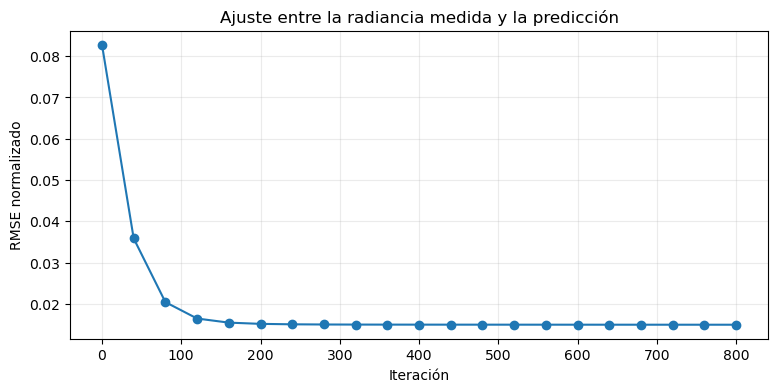

In [11]:
#@title **Visualizar la convergencia de la medición**
history = inverse_result["history"]
iterations = [row["iteration"] for row in history]

plt.figure(figsize=(9, 4))
plt.plot(iterations, [row["radiance_rmse"] for row in history], marker="o")
plt.xlabel("Iteración")
plt.ylabel("RMSE normalizado")
plt.title("Ajuste entre la radiancia medida y la predicción")
plt.grid(alpha=0.25)
plt.show()

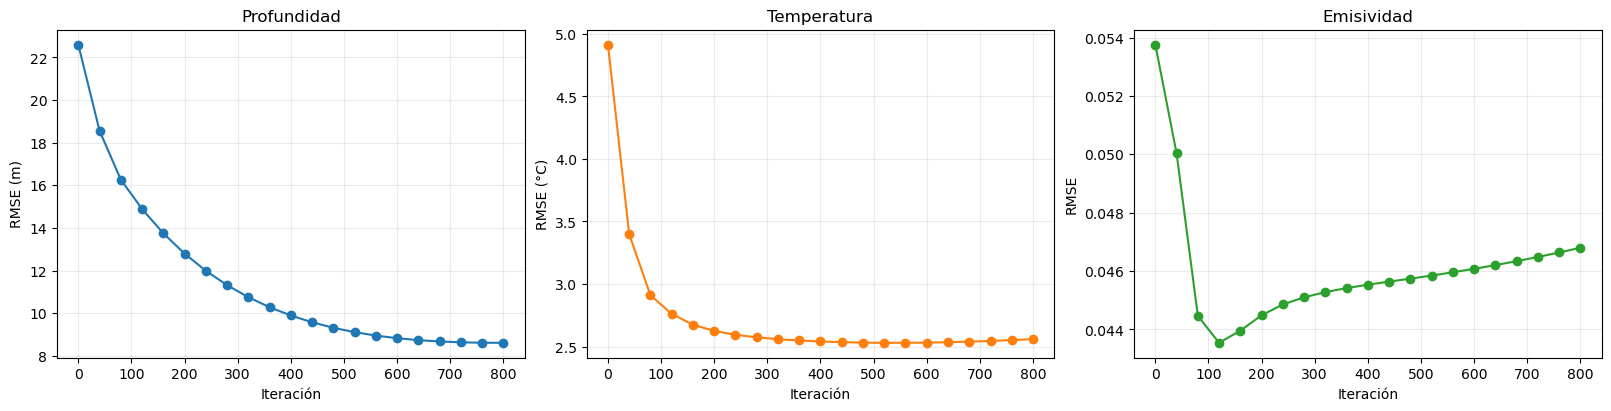

In [12]:
#@title **Comparar los errores de los parámetros estimados**
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
metrics = [
    ("depth_rmse", "Profundidad", "RMSE (m)", "tab:blue"),
    ("temperature_rmse", "Temperatura", "RMSE (°C)", "tab:orange"),
    ("emissivity_rmse", "Emisividad", "RMSE", "tab:green"),
]

for axis, (key, title, ylabel, color) in zip(axes, metrics):
    axis.plot(iterations, [row[key] for row in history], marker="o", color=color)
    axis.set_title(title)
    axis.set_xlabel("Iteración")
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.25)

plt.show()

# <font color="4C5FDA"> **5. Evaluar la profundidad estimada** </font><a id="tema5"></a>

Reconstruiremos el mapa con la misma geometría de la muestra espacial. El cielo se deja en blanco porque no fue parte de la optimización.

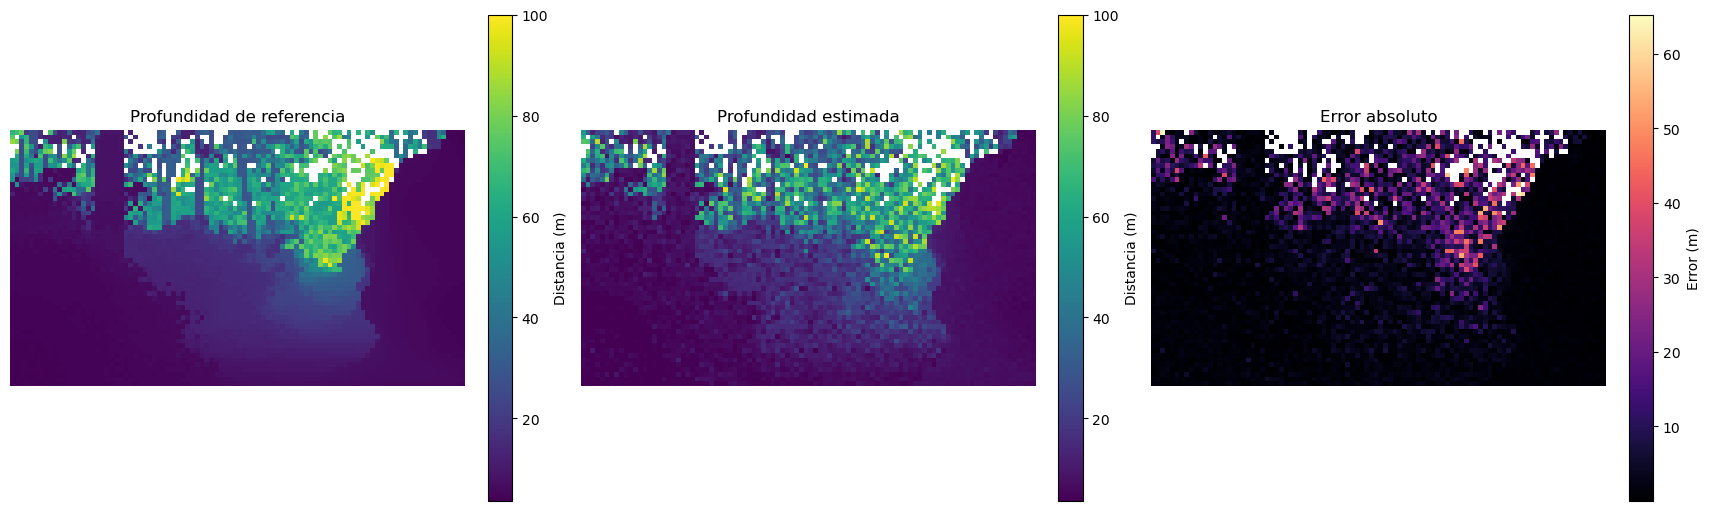

In [13]:
#@title **Comparar la profundidad de referencia y la estimada**
depth_prediction = np.full(depth_truth.shape, np.nan, dtype=np.float32)
depth_prediction[object_mask] = inverse_result["depth"]
depth_error = np.abs(depth_prediction - np.where(object_mask, depth_truth, np.nan))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
vmin = float(np.nanmin(depth_truth[object_mask]))
vmax = float(np.nanmax(depth_truth[object_mask]))

truth_image = axes[0].imshow(
    np.where(object_mask, depth_truth, np.nan), cmap="viridis", vmin=vmin, vmax=vmax
)
axes[0].set_title("Profundidad de referencia")
axes[0].axis("off")
fig.colorbar(truth_image, ax=axes[0], label="Distancia (m)")

prediction_image = axes[1].imshow(depth_prediction, cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Profundidad estimada")
axes[1].axis("off")
fig.colorbar(prediction_image, ax=axes[1], label="Distancia (m)")

error_image = axes[2].imshow(depth_error, cmap="magma")
axes[2].set_title("Error absoluto")
axes[2].axis("off")
fig.colorbar(error_image, ax=axes[2], label="Error (m)")
plt.show()

# <font color="4C5FDA"> **6. Analizar la temperatura y la emisividad espectral** </font><a id="tema6"></a>

La profundidad es el resultado principal, pero el mismo backward también entrega una temperatura y una firma de emisividad para cada píxel.

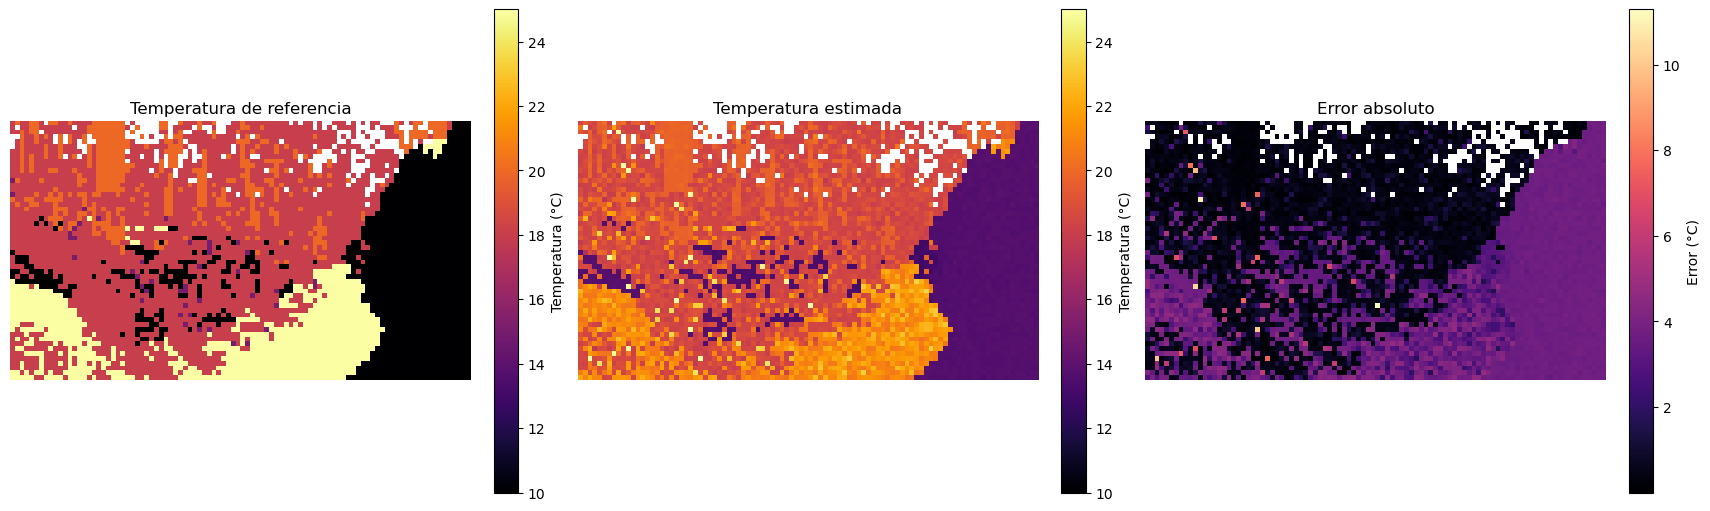

In [14]:
#@title **Comparar la temperatura de referencia y la estimada**
temperature_prediction = np.full(temperature_truth_c.shape, np.nan, dtype=np.float32)
temperature_prediction[object_mask] = inverse_result["temperature_c"]
temperature_error = np.abs(
    temperature_prediction - np.where(object_mask, temperature_truth_c, np.nan)
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
vmin = float(np.nanmin(temperature_truth_c[object_mask]))
vmax = float(np.nanmax(temperature_truth_c[object_mask]))

truth_image = axes[0].imshow(
    np.where(object_mask, temperature_truth_c, np.nan), cmap="inferno", vmin=vmin, vmax=vmax
)
axes[0].set_title("Temperatura de referencia")
axes[0].axis("off")
fig.colorbar(truth_image, ax=axes[0], label="Temperatura (°C)")

prediction_image = axes[1].imshow(
    temperature_prediction, cmap="inferno", vmin=vmin, vmax=vmax
)
axes[1].set_title("Temperatura estimada")
axes[1].axis("off")
fig.colorbar(prediction_image, ax=axes[1], label="Temperatura (°C)")

error_image = axes[2].imshow(temperature_error, cmap="magma")
axes[2].set_title("Error absoluto")
axes[2].axis("off")
fig.colorbar(error_image, ax=axes[2], label="Error (°C)")
plt.show()

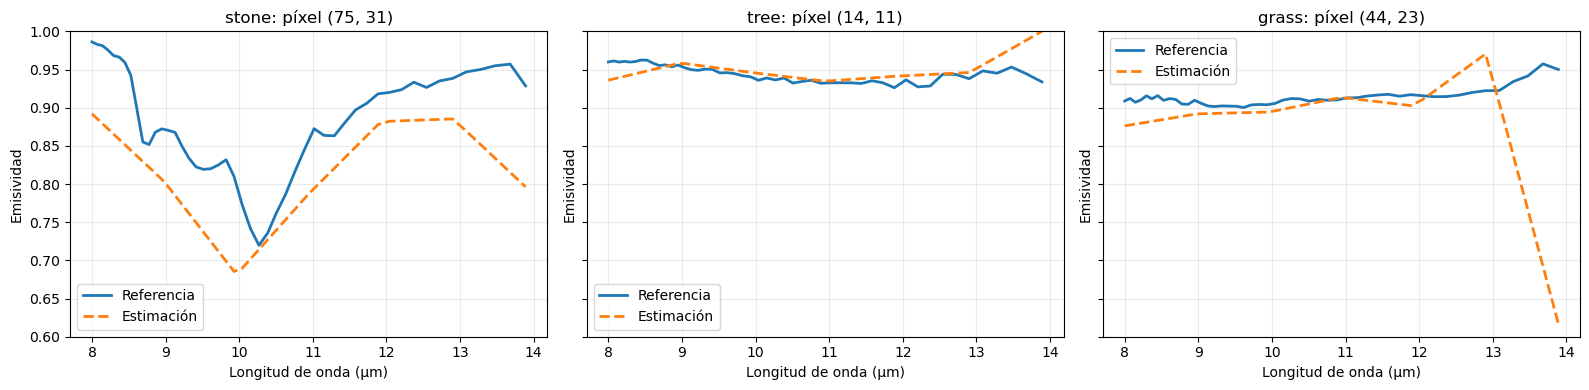

In [15]:
#@title **Comparar firmas de emisividad espectral**
emissivity_prediction = np.full(emissivity_truth.shape, np.nan, dtype=np.float32)
emissivity_prediction[object_mask] = inverse_result["emissivity"]

selected_materials = ["stone", "tree", "grass"]
selected_pixels = []
for material_name in selected_materials:
    material_id = int(np.where(material_names == material_name)[0][0])
    candidates = np.argwhere((material_map == material_id) & object_mask)
    selected_pixels.append((*candidates[len(candidates) // 2], material_name))

fig, axes = plt.subplots(1, len(selected_pixels), figsize=(16, 4), sharey=True)
for axis, (row, column, material_name) in zip(axes, selected_pixels):
    axis.plot(
        wavelengths,
        emissivity_truth[row, column],
        label="Referencia",
        linewidth=2,
    )
    axis.plot(
        wavelengths,
        emissivity_prediction[row, column],
        label="Estimación",
        linestyle="--",
        linewidth=2,
    )
    axis.set_title(f"{material_name}: píxel ({column}, {row})")
    axis.set_xlabel("Longitud de onda (µm)")
    axis.set_ylabel("Emisividad")
    axis.set_ylim(0.6, 1.0)
    axis.grid(alpha=0.25)
    axis.legend()

plt.tight_layout()
plt.show()

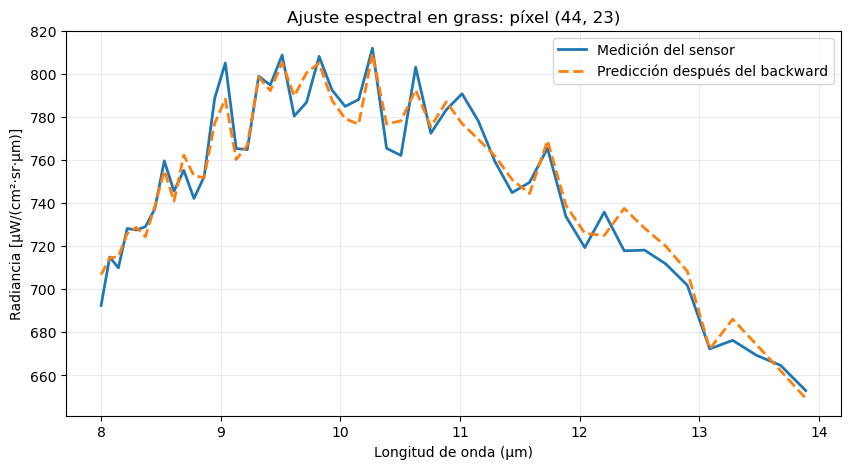

In [16]:
#@title **Comprobar el ajuste espectral final**
pixel_y, pixel_x, material_name = selected_pixels[-1]
object_positions = np.full(object_mask.shape, -1, dtype=np.int32)
object_positions[object_mask] = np.arange(object_mask.sum())
object_index = object_positions[pixel_y, pixel_x]

plt.figure(figsize=(10, 5))
plt.plot(
    wavelengths,
    sensor_cube[pixel_y, pixel_x],
    label="Medición del sensor",
    linewidth=2,
)
plt.plot(
    wavelengths,
    inverse_result["radiance"][object_index],
    label="Predicción después del backward",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Longitud de onda (µm)")
plt.ylabel("Radiancia [µW/(cm²·sr·µm)]")
plt.title(f"Ajuste espectral en {material_name}: píxel ({pixel_x}, {pixel_y})")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## Resultado

Tratamos el cubo térmico exactamente como cualquier otra medición multibanda: definimos un modelo diferenciable, comparamos su predicción con los datos y propagamos el error hacia los parámetros de la escena.

Esta primera versión prioriza claridad sobre precisión. La emisividad se representa con pocos puntos de control, la atmósfera se asume conocida y no imponemos todavía continuidad espacial. Estas decisiones hacen que el ejemplo sea pequeño y funcional, y también señalan las extensiones naturales para una siguiente iteración.